# Evaluating Human Preference Data for Code Generation Models

## Overview
This notebook explores how human preference data can be analyzed to improve the training quality of code generation models.

Large language models for coding rely heavily on human-labeled preference data. However, issues such as **label noise** and **annotator reliability** can significantly affect model performance.

## Objectives
In this notebook, I explore several key questions:

1. What is the structure of the preference dataset?
2. How consistent are human annotators?
3. Where might label noise occur?
4. How can we improve training data quality?

## Skills Demonstrated
- Python data analysis
- Exploratory Data Analysis (EDA)
- Human feedback dataset analysis
- AI evaluation reasoning
- Annotator reliability analysis

## Tools Used
- Python
- Pandas
- NumPy
- Jupyter / Google Colab

## Why this matters
As AI systems increasingly rely on human feedback for training, **data quality and annotator reliability become critical factors in building safe and effective models.**

# Problem Framing

Training AI systems to generate high-quality code requires reliable human feedback. However, human-labeled datasets can introduce challenges such as:

- Label noise
- Annotator disagreement
- Inconsistent evaluation criteria

This analysis investigates how these factors appear in the dataset and how they might impact model training.




## Goal of the Model

The goal is to train a code generation model that can produce **correct, efficient, and reliable code solutions**.

To achieve this, models are often trained using **human preference data**, where annotators evaluate multiple generated responses and indicate which one is better.

High-quality preference data helps models learn:

- correct coding patterns
- good reasoning strategies
- reliable outputs

## Model Evaluation Metrics

Several metrics can be used to evaluate the performance of code generation models:

**Unit Test Pass Rate**
- Measures whether generated code passes predefined tests.

**Pass@k**
- Measures whether at least one of the top *k* generated solutions is correct.

**BLEU Score**
- Measures similarity between generated code and reference solutions.

**Runtime Error Rate**
- Measures how often generated code fails due to execution errors.

These metrics help evaluate whether improvements in the training dataset translate into better model performance.

## Dataset Source

This analysis uses the **HelpSteer3 dataset**, released by NVIDIA and available through HuggingFace.

HelpSteer3 is a human preference dataset used to improve alignment of large language models through supervised fine-tuning and reinforcement learning from human feedback (RLHF).

Dataset link:
https://huggingface.co/datasets/nvidia/HelpSteer3

Each row contains:
- multiple model responses
- human preference annotations
- an aggregated overall preference

These annotations allow us to analyze:
- annotator agreement
- label noise
- reliability of human feedback signals

# Dataset Exploration

Before analyzing annotator behavior, we first explore the structure of the dataset.

Key questions:
- What variables are included?
- How are preferences represented?
- How balanced are the labels?

In [1]:
import pandas as pd

splits = {'train': 'preference/train.jsonl.gz', 'validation': 'preference/validation.jsonl.gz'}
preference_df = pd.read_json("hf://datasets/nvidia/HelpSteer3/" + splits["train"], lines=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
preference_df.head()

,domain,language,context,response1,response2,overall_preference,individual_preference
0,code,python,"[{'role': 'user', 'content': 'lets do python c...","Yes, you are correct. The correct comparison o...",Sure! Here's the updated line of code with `<`...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."
1,code,python,"[{'role': 'user', 'content': '1. Hello :) Toda...","Y, I understand how Midjourney works based on ...",READ,-3,"[{'score': -3, 'reasoning': '@Response 1 is mu..."
2,code,javascript_html_css,"[{'role': 'user', 'content': 'Hello. I am a Fa...",I'm glad to hear that you understand the impo...,"I understand, and I apologize if my response c...",1,"[{'score': 1, 'reasoning': '@Response 2 is sli..."
3,code,go,"[{'role': 'user', 'content': 'We have an objec...","To achieve this in Go, you can use the `githu...","To achieve this, you can use the `HSETNX` comm...",-1,"[{'score': -1, 'reasoning': '@Response 1 is sl..."
4,code,python,"[{'role': 'user', 'content': 'generate apache ...",```python\nfrom flask import Flask\nfrom flask...,To add database migration support using Flask-...,-1,"[{'score': -1, 'reasoning': '@Response 1 is sl..."


In [3]:
preference_df.describe().round(2)

,overall_preference
count,38459.00
mean,-0.00
std,1.95
min,-3.00
25%,-2.00
50%,0.00
75%,2.00
max,3.00


In [4]:
preference_df['overall_preference'].mode()

,overall_preference
0,-2


In [5]:
preference_df['overall_preference'].value_counts()

,count
overall_preference,
-2,8387
2,7973
1,6398
-1,5942
3,3831
-3,3768
0,2160


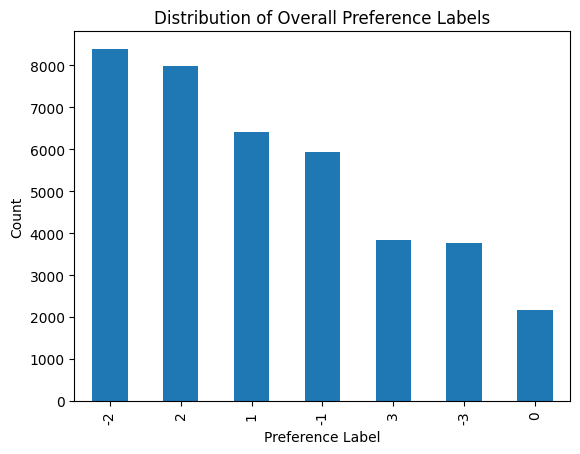

In [6]:
import matplotlib.pyplot as plt

preference_df['overall_preference'].value_counts().plot(
    kind='bar',
    title='Distribution of Overall Preference Labels'
)

plt.xlabel("Preference Label")
plt.ylabel("Count")
plt.show()

In [7]:
preference_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38459 entries, 0 to 38458
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   domain                 38459 non-null  object
 1   language               38459 non-null  object
 2   context                38459 non-null  object
 3   response1              38459 non-null  object
 4   response2              38459 non-null  object
 5   overall_preference     38459 non-null  int64 
 6   individual_preference  38459 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.1+ MB


In [8]:
preference_df.iloc[0]['individual_preference']

[{'score': -2,
  'reasoning': '@Response 1 is better than @Response 2 because @Response 1 provides a full code example, integrating the required change directly into the main function, making it immediately usable for the user. @Response 2, while technically correct, only addresses part of the problem by showing a single line change without embedding it into the overall code, leaving more work for the user to complete the solution.',
  'feedback1': "The response is perfectly helpful. This is because it provides the full code with the correct modification as requested in the prompt. It clearly explains that the comparison operator < has replaced <= and ensures the change is implemented in the full function. The explanation is concise, the code is functional, and it meets the user's needs, making it an excellent and complete solution.",
  'feedback2': 'The response is partially helpful. This is because while it correctly updates the comparison operator from <= to <, it only provides a sm

## Label Noise

Label noise occurs when the recorded label does not accurately represent the true preference signal.

In preference datasets, label noise may arise from several sources:

Primary sources:
- **Annotator disagreement**, where individual preferences differ significantly
- **Misalignment between individual preferences and the aggregated overall preference**

In this analysis, I identify potential label noise when:

- the **individual preference agreement rate ≤ 0.6**
- there is strong disagreement among annotators

Secondary sources:
- **Low annotation counts**, where only 1–2 annotators evaluated a sample

Low annotation counts increase uncertainty because there is insufficient consensus to establish a reliable label.

## Annotator Quality

Not all annotators provide equally reliable judgments.

To estimate annotator reliability, I compare each annotator’s preference with the dataset's aggregated **overall preference**.

Hypothesis:
If an annotator frequently agrees with the overall preference, their annotations are likely more reliable.

Annotator reliability score:

reliability = agreement_with_overall_preference / total_annotations

This score measures how often an annotator aligns with the consensus decision.

Higher scores indicate stronger alignment with the dataset’s consensus signal.

In [9]:
# Annotator agreement
preference_df['individual_preference'].apply(len).unique()


array([3, 2, 1])

In [10]:
preference_df['individual_preference'].apply(len).value_counts()

,count
individual_preference,
3,37241
2,733
1,485


In [11]:
# I want to grab the rows with 3 annotator

df_3_annotators = preference_df[preference_df['individual_preference'].apply(len) == 3]

df_3_annotators.head()

,domain,language,context,response1,response2,overall_preference,individual_preference
0,code,python,"[{'role': 'user', 'content': 'lets do python c...","Yes, you are correct. The correct comparison o...",Sure! Here's the updated line of code with `<`...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."
1,code,python,"[{'role': 'user', 'content': '1. Hello :) Toda...","Y, I understand how Midjourney works based on ...",READ,-3,"[{'score': -3, 'reasoning': '@Response 1 is mu..."
2,code,javascript_html_css,"[{'role': 'user', 'content': 'Hello. I am a Fa...",I'm glad to hear that you understand the impo...,"I understand, and I apologize if my response c...",1,"[{'score': 1, 'reasoning': '@Response 2 is sli..."
3,code,go,"[{'role': 'user', 'content': 'We have an objec...","To achieve this in Go, you can use the `githu...","To achieve this, you can use the `HSETNX` comm...",-1,"[{'score': -1, 'reasoning': '@Response 1 is sl..."
4,code,python,"[{'role': 'user', 'content': 'generate apache ...",```python\nfrom flask import Flask\nfrom flask...,To add database migration support using Flask-...,-1,"[{'score': -1, 'reasoning': '@Response 1 is sl..."


In [12]:
# I want to grab the first score in the individual_preference and compare it to the overall preference.
# Do the same with second and third score.
# Save the result in another dataframe.

df_temp_3 = df_3_annotators.copy()

df_temp_3['annotator1'] = df_temp_3['individual_preference'].apply(lambda x: x[0]['score'])
df_temp_3['annotator2'] = df_temp_3['individual_preference'].apply(lambda x: x[1]['score'])
df_temp_3['annotator3'] = df_temp_3['individual_preference'].apply(lambda x: x[2]['score'])


df_temp_3['a1_match'] = df_temp_3['annotator1'] == df_temp_3['overall_preference']
df_temp_3['a2_match'] = df_temp_3['annotator2'] == df_temp_3['overall_preference']
df_temp_3['a3_match'] = df_temp_3['annotator3'] == df_temp_3['overall_preference']

df_result_3 = df_temp_3[['overall_preference',
                     'annotator1','annotator2','annotator3',
                     'a1_match','a2_match','a3_match']]

df_result_3['agreement_rate'] = df_result_3[['a1_match','a2_match','a3_match']].mean(axis=1)

# Primary Label noise!!
df_result_3[df_result_3['agreement_rate'] <= 0.6]




/tmp/ipykernel_189/3814369652.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_3['agreement_rate'] = df_result_3[['a1_match','a2_match','a3_match']].mean(axis=1)


,overall_preference,annotator1,annotator2,annotator3,a1_match,a2_match,a3_match,agreement_rate
13,-2,-3,-2,-1,False,True,False,0.333333
20,-2,-2,-3,-1,True,False,False,0.333333
56,-2,-1,-3,-2,False,False,True,0.333333
60,2,3,1,3,False,False,False,0.000000
64,-2,-1,-1,-3,False,False,False,0.000000
...,...,...,...,...,...,...,...,...
38441,2,1,1,3,False,False,False,0.000000
38442,0,-1,1,1,False,False,False,0.000000
38452,0,-1,1,1,False,False,False,0.000000
38454,-2,-2,-3,-1,True,False,False,0.333333


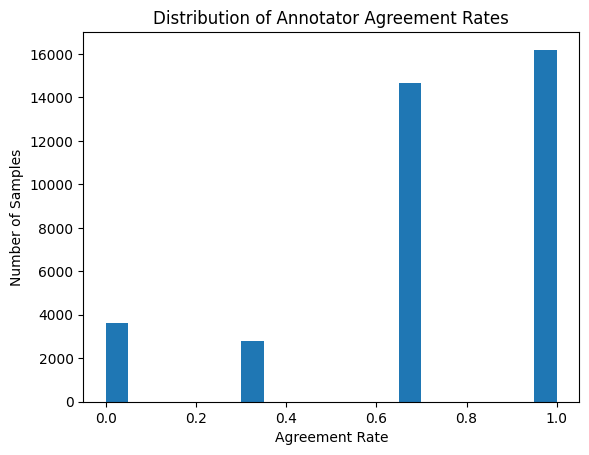

In [13]:
plt.hist(df_result_3['agreement_rate'], bins=20)

plt.title("Distribution of Annotator Agreement Rates")
plt.xlabel("Agreement Rate")
plt.ylabel("Number of Samples")
plt.show()

In [14]:
# I want to grab the rows with 2 annotator

df_2_annotators = preference_df[preference_df['individual_preference'].apply(len) == 2]

# Secondary label noise
df_2_annotators.head()

,domain,language,context,response1,response2,overall_preference,individual_preference
515,code,javascript_html_css,"[{'role': 'user', 'content': 'how can I formul...","I have reviewed the source code, and it appear...",I apologize for any confusion. I have reviewed...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."
674,code,python,"[{'role': 'user', 'content': 'write a python c...","You're right, I apologize for the oversight. H...","You're right, I apologize for the oversight. T...",2,"[{'score': 2, 'reasoning': '@Response 2 is bet..."
1552,code,r,"[{'role': 'user', 'content': 'Write R code tha...","Yes, the `is.numeric()` function in R is vecto...","No, the `is.numeric` function in R is not vect...",-2,"[{'score': -1, 'reasoning': '@Response 1 is sl..."
2056,code,python,"[{'role': 'user', 'content': 'can you provide ...",Langchain is a hypothetical concept and there'...,I'd be happy to explain the structure of Langc...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."
3030,code,javascript_html_css,"[{'role': 'user', 'content': 'Please write a J...","You are correct, my apologies for the oversigh...",You are absolutely right! \n\nThe variable `i...,0,"[{'score': 1, 'reasoning': '@Response 2 is sli..."


In [15]:
# I want to grab the first score in the individual_preference and compare it to the overall preference.
# Do the same with second score.
# Save the result in another dataframe.

df_temp_2 = df_2_annotators.copy()

df_temp_2['annotator1'] = df_temp_2['individual_preference'].apply(lambda x: x[0]['score'])
df_temp_2['annotator2'] = df_temp_2['individual_preference'].apply(lambda x: x[1]['score'])


df_temp_2['a1_match'] = df_temp_2['annotator1'] == df_temp_2['overall_preference']
df_temp_2['a2_match'] = df_temp_2['annotator2'] == df_temp_2['overall_preference']

df_result_2 = df_temp_2[['overall_preference',
                     'annotator1','annotator2',
                     'a1_match','a2_match']]

df_result_2['agreement_rate'] = df_result_2[['a1_match','a2_match']].mean(axis=1)

# Primary Label noise!!
df_result_2[df_result_2['agreement_rate'] <= 0.6]

/tmp/ipykernel_189/1224999389.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_2['agreement_rate'] = df_result_2[['a1_match','a2_match']].mean(axis=1)


,overall_preference,annotator1,annotator2,a1_match,a2_match,agreement_rate
674,2,2,1,True,False,0.5
1552,-2,-1,-3,False,False,0.0
3030,0,1,-1,False,False,0.0
3335,2,3,2,False,True,0.5
3799,-2,-2,-3,True,False,0.5
...,...,...,...,...,...,...
38250,2,2,3,True,False,0.5
38288,2,2,3,True,False,0.5
38296,-2,-3,-2,False,True,0.5
38377,0,-1,1,False,False,0.0


In [16]:
# I want to grab the rows with 1 annotator

df_1_annotator = preference_df[preference_df['individual_preference'].apply(len) == 1]

df_1_annotator.head()

,domain,language,context,response1,response2,overall_preference,individual_preference
846,code,python,"[{'role': 'user', 'content': 'perform instruct...","1. To calculate the value of the tag word, we ...",1. Calculate the value of the tag word:\n\nGiv...,3,"[{'score': 3, 'reasoning': '@Response 2 is muc..."
909,code,javascript_html_css,"[{'role': 'user', 'content': 'can you please c...","Sure, I'd be happy to help you create a waving...",```html\n<!DOCTYPE html>\n<html>\n<head>\n<tit...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."
1063,code,python,"[{'role': 'user', 'content': 'write python cod...",Apologies for the confusion. The `truetype()` ...,I apologize for the confusion. The `ImageFont....,2,"[{'score': 2, 'reasoning': '@Response 2 is bet..."
1537,code,python,"[{'role': 'user', 'content': 'You will obey th...",```python\nimport base64\n\ndef decode_twice(e...,"Sure, I'll follow your rules. Here's the twice...",-1,"[{'score': -1, 'reasoning': '@Response 1 is sl..."
1721,code,javascript_html_css,"[{'role': 'user', 'content': 'can you please c...","Sure, I'd be happy to help you create a waving...",```html\n<!DOCTYPE html>\n<html>\n<head>\n<tit...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."


In [17]:
# I want to grab the first score in the individual_preference and compare it to the overall preference.
# Save the result in another dataframe.

df_temp_1 = df_1_annotator.copy()

df_temp_1['annotator1'] = df_temp_1['individual_preference'].apply(lambda x: x[0]['score'])


df_temp_1['a1_match'] = df_temp_1['annotator1'] == df_temp_1['overall_preference']

df_result_1 = df_temp_1[['overall_preference',
                     'annotator1',
                     'a1_match']]

df_result_1['agreement_rate'] = df_result_1[['a1_match']].mean(axis=1)



# Primary Label noise!! (Which is 0)
df_result_1[df_result_1['agreement_rate'] <=0.6]


/tmp/ipykernel_189/3293627263.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_1['agreement_rate'] = df_result_1[['a1_match']].mean(axis=1)


,overall_preference,annotator1,a1_match,agreement_rate


In [18]:
# Calculate annotator reliability

scores = preference_df['individual_preference'].apply(
    lambda x: [d['score'] for d in x]
)

votes = pd.DataFrame(scores.tolist(), index=preference_df.index)

matches = votes.eq(preference_df['overall_preference'], axis=0)

annotator_reliability = matches.mean()

reliability_df = annotator_reliability.reset_index()
reliability_df.columns = ['annotator_position', 'reliability_score']

reliability_df

,annotator_position,reliability_score
0,0,0.720976
1,1,0.712863
2,2,0.699498


In [19]:
# Primary Label Noise
df_result_3[df_result_3['agreement_rate'] <= 0.6] # 3 annotators but the agreement rate is less than equal to 60%.
df_result_2[df_result_2['agreement_rate'] <= 0.6] # 2 annotators but the agreement rate is less than equal to 60%.
df_result_1[df_result_1['agreement_rate'] <=0.6] # 1 annotator but the agreement rate is less than equal to 60%. (Which is 0)

# Secondary label noise
df_2_annotators.head() # 2 annotators
df_1_annotator.head() # 1 annotators



,domain,language,context,response1,response2,overall_preference,individual_preference
846,code,python,"[{'role': 'user', 'content': 'perform instruct...","1. To calculate the value of the tag word, we ...",1. Calculate the value of the tag word:\n\nGiv...,3,"[{'score': 3, 'reasoning': '@Response 2 is muc..."
909,code,javascript_html_css,"[{'role': 'user', 'content': 'can you please c...","Sure, I'd be happy to help you create a waving...",```html\n<!DOCTYPE html>\n<html>\n<head>\n<tit...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."
1063,code,python,"[{'role': 'user', 'content': 'write python cod...",Apologies for the confusion. The `truetype()` ...,I apologize for the confusion. The `ImageFont....,2,"[{'score': 2, 'reasoning': '@Response 2 is bet..."
1537,code,python,"[{'role': 'user', 'content': 'You will obey th...",```python\nimport base64\n\ndef decode_twice(e...,"Sure, I'll follow your rules. Here's the twice...",-1,"[{'score': -1, 'reasoning': '@Response 1 is sl..."
1721,code,javascript_html_css,"[{'role': 'user', 'content': 'can you please c...","Sure, I'd be happy to help you create a waving...",```html\n<!DOCTYPE html>\n<html>\n<head>\n<tit...,-2,"[{'score': -2, 'reasoning': '@Response 1 is be..."


In [20]:
# Annotator reliability
reliability_df

,annotator_position,reliability_score
0,0,0.720976
1,1,0.712863
2,2,0.699498


# Data Quality Improvement Strategy

To improve training data quality, I propose a weighting framework that reduces the impact of noisy annotations.

The weighting strategy considers three factors:

1. Annotator reliability
2. Annotator agreement
3. Number of annotators per sample

## Step 1: Annotator Reliability

Annotator reliability scores are normalized using **Min-Max normalization**:

normalized_score = (score - min) / (max - min)

This ensures all annotator scores fall between 0 and 1.

Samples with annotations from more reliable annotators receive higher weight.

## Step 2: Agreement Weight

Agreement levels determine the reliability of preference labels.

Agreement Rate → Weight

1.0 → 1.0  
0.6–1.0 → 0.67  
≤0.6 → 0.33  

Lower agreement reduces the contribution of potentially noisy labels.

## Step 3: Annotator Count Weight

The number of annotators also affects label reliability.

Annotator Count → Weight

3 annotators → 1.0  
2 annotators → 0.67  
1 annotator → 0.33  

Samples with more annotators provide stronger consensus signals.

## Final Weighted Score

The final training weight for each sample is computed as:

Final Weight =
(average annotator reliability)
× (agreement weight)
× (annotator count weight)

This framework ensures that:

- reliable annotators contribute more
- high-agreement samples contribute more
- samples with more annotations contribute more

# Evaluating Impact on Model Performance

To evaluate whether data quality improvements help model training, we can compare:

Original training dataset  
vs  
Reweighted dataset

Evaluation methods:

**A/B testing**
Train two models using the different datasets and compare results.

**Evaluation metrics**

- Unit Test Pass Rate
- Pass@k
- BLEU Score
- Runtime Error Rate
- Human evaluation

If the reweighted dataset improves these metrics, it suggests that reducing label noise and weighting annotator reliability improves model performance.

## Key Takeaway

This notebook explores how label noise and annotator reliability affect human preference datasets, and proposes a weighting strategy to improve the quality of training signals used in AI alignment pipelines.